# Circular words and their rewrite rules

The words layer of `DiagrammaticHecke.jl`. Everything here is purely
combinatorial: the letters `1, 2, 3` are bare symbols (secretly the simple
reflections of type A₃, but no group theory enters this layer).

Kernel = this project's environment; start Jupyter from the package root with
`julia --project=. -e 'using IJulia; notebook(dir=".")'`.

In [1]:
using DiagrammaticHecke

## 1. Circular words

A `CircularWord` is a word over `{1,2,3}` up to **cyclic rotation**:
$(i_1 i_2 \dots i_n) \equiv (i_2 \dots i_n i_1)$. It is stored in its normal
form, the lexicographically smallest rotation, so `==` and `hash` test equality
of the underlying cyclic element. The empty word is `EMPTY` (printed `ε`).

In [2]:
w = CircularWord([1,3,1,2])
@show w
@show CircularWord([3,1,2,1]) == w   # a rotation: the same element
@show letters(w) compact(w) length(w)
rotations(w)

w = 

CircularWord(1213)


CircularWord([3, 1, 2, 1]) == w = true


letters(w) = [1, 2, 1, 3]
compact(w) = 

"1213"
length(w) = 

4


4-element Vector{Vector{Int64}}:
 [1, 2, 1, 3]
 [2, 1, 3, 1]
 [1, 3, 1, 2]
 [3, 1, 2, 1]

## 2. The rules

The base rules, each usable in both directions and applied **cyclically**
(a window may wrap around the seam). The names are the pictures they draw:

| rule | Δlength | sign | name | what it draws |
|---|---|---|---|---|
| `ii ↔ ε` (i = 1,2,3) | ∓2 | −1 / +1 | `cap` | the two i-strands join into one arc and close off |
| `ii ↔ i` (i = 1,2,3) | ∓1 | −1 / +1 | `merge` | the two i-strands run into one trivalent |
| `13 ↔ 31` | 0 | 0 | `comm` | the 1- and 3-strand cross |
| `121 ↔ 212`, `232 ↔ 323` | 0 | 0 | `braid` | the braid generator |

`dot` is the name of `i ↔ ε`, one strand capped by a dot, and it is deliberately
NOT here: with it every word would reach ε one letter at a time, and the
reachability question of section 3 would be vacuous.

These are the type-A₃ Coxeter relations plus the two idempotency rules. The
**sign** of a move (−1 reducing, 0 neutral, +1 increasing) is the edge label in
the reduction graph.

In [3]:
BASE_RULES

9-element Vector{Rule}:
 Rule([1, 1], Int64[], :cap1)
 Rule([2, 2], Int64[], :cap2)
 Rule([3, 3], Int64[], :cap3)
 Rule([1, 1], [1], :merge1)
 Rule([2, 2], [2], :merge2)
 Rule([3, 3], [3], :merge3)
 Rule([1, 3], [3, 1], :comm_13)
 Rule([1, 2, 1], [2, 1, 2], :braid_12)
 Rule([2, 3, 2], [3, 2, 3], :braid_23)

**Cyclic application matters.** In `1312` the braid pattern `121` sits at the
cyclic positions (3, 4, 1) — it wraps around the seam — and rewriting gives
`2321`. (Both words print in normal form: `1312` as `1213` and the result
`2321` as `1232` — the same cyclic elements.)

In [4]:
[m for m in moves(w) if m.rule == :braid_12]

1-element Vector{Move}:
 Move(CircularWord(1232), 0, :braid_12, 1, true)

`neighbors(w)` deduplicates the moves to distinct resulting words, each paired
with its sign. From `ε` only increasing moves exist (inserting `ii`):

In [5]:
@show neighbors(w)
neighbors(EMPTY)

neighbors(w) = Tuple{CircularWord, Int64}[(CircularWord(1232), 0), (CircularWord(111312), 1), (CircularWord(121333), 1), (CircularWord(1123), 0), (CircularWord(121223), 1), (CircularWord(131332), 1), (CircularWord(121322), 1), (CircularWord(123313), 1), (CircularWord(12133), 1), (CircularWord(12213), 1), (CircularWord(11213), 1), (CircularWord(1132), 0), (CircularWord(11312), 1), (CircularWord(111213), 1), (CircularWord(122213), 1)]


3-element Vector{Tuple{CircularWord, Int64}}:
 (CircularWord(11), 1)
 (CircularWord(33), 1)
 (CircularWord(22), 1)

## 3. Derived reducers and directed move sets

`EXTRA_REDUCERS` are strictly-reducing shortcuts derivable from the base rules
(e.g. `121212 → ε`, `1212 → 21`, `131 → 3`); `EXTENDED_RULES` = base ∪ extra.
Two directed views on top of them:

- `down_neighbors(w)` — non-increasing moves only (all reducers + the neutral
  braid/commutation moves). This is the move set for the central question:
  *which circular words reduce to ε?*
- `up_neighbors(w)` — strictly increasing moves with a nonempty source
  (`UP_RULES`); the ε-exits `ε → ii, …` are deliberately excluded and only
  ever used as the first step of an upward walk.

In [6]:
@show down_neighbors(CircularWord([1,2,1,2,1,2]))   # reaches ε directly
@show down_neighbors(CircularWord([1]))             # nothing non-increasing
up_neighbors(CircularWord([1]))

down_neighbors(CircularWord([1, 2, 1, 2, 1, 2])) = Tuple{CircularWord, Int64}[(CircularWord(22), -1), (CircularWord(1122), -1), (CircularWord(ε), -1), (CircularWord(112112), 0), (CircularWord(122122), 0)]
down_neighbors(CircularWord([1])) = Tuple{CircularWord, Int64}[]


2-element Vector{CircularWord}:
 CircularWord(11)
 CircularWord(133)

## 4. Braid-expander tilings

For the *expand-then-reduce* search we use the eight **braid expanders**
(`12 → 2121`, `21 → 1212`, `2 → 12121`, … and the `{2,3}` mirror images).
A word *fully expands* if its positions admit a disjoint cyclic tiling by
expander left-hand sides. Example: `1221` tiles as `12 | 21` and expands to
`21211212`, which then reduces to `ε`.

In [7]:
v = CircularWord([1,2,2,1])
@show has_full_expansion(v)
ex = a_full_expansion(v)
@show ex.rotation ex.blocks ex.result
increasing_expansions(v)

has_full_expansion(v) = 

true
ex.rotation = 

[1, 1, 2, 2]


ex.blocks = [([1], [2, 1, 2, 1, 2]), ([1, 2], [2, 1, 2, 1]), ([2], [1, 2, 1, 2, 1])]
ex.result = CircularWord(11212121212212)


9-element Vector{CircularWord}:
 CircularWord(11212212121212)
 CircularWord(12122121323232)
 CircularWord(12121212132323212122)
 CircularWord(12122121232323323232)
 CircularWord(11212121212212121212)
 CircularWord(11212121212212)
 CircularWord(11212212)
 CircularWord(12121212122121232323)
 CircularWord(12122121232323)

## 5. What a circular word draws

A circular word is the boundary of a planar diagram, and every rule above is a
relation between diagrams. The braid rule `121 ↔ 212` is the 6-valent braid
node, whose boundary is exactly the circular word `121212` used in §3.
Chapters 3 and 5 build these diagrams; here it is only a picture.

compact(b.word) = 

"121212"


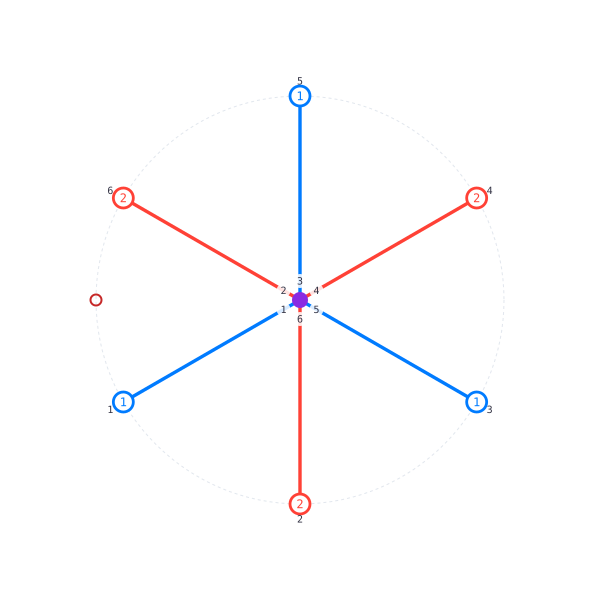

In [8]:
b = braid(1, 2; m = 3)
@show compact(b.word)
display(b)